In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Contexto

Análise da performance do estimador MCMC em redes bayesianas sintéticas, versus o cálculo exato conforme proposto por "Algorithms and Applications for the Same-Decision Probability, Choi, Chen, & Darwiche (2014). JAIR 2014"

Design do experimento: são definidos os seguintes fatores:
 - Número de nós: variando de 10 a 80
 - Densidade da rede (em função da induced width, conforme Generating Random Bayesian Networks with Constraints on Induced Width Jaime S. Ide and Fabio G. Cozman and Fabio T. Ramos): variando entre esparsa, média e densa
 - Rigidez das probabilidades condicionais: variando entre Rígida (det) e Fuzzy

O dataset gerado é composto por resultados de 20 execuções do MCMC e 1 execução do exato, para cada rede gerada. São buscados conjuntos de evidência para tentar mapear valores exatos de SDP entre 0.5 e 1, mas nem sempre é possível encontrar todos. Para redes acima de 60 nós, a versão densa pode fazer o exato falhar por falta de memória. 

# Primeira análise exploratória

In [23]:
df = pd.read_csv("/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/targeted_sdp_random_bns_with_entropy.csv")

In [29]:
df.columns

Index(['Network', 'N_Nodes', 'Density', 'Rigidity', 'Target_Bucket',
       'Target_Node', 'Target_Value', 'Exact_SDP', 'Exact_Time_sec',
       'MCMC_Mean_SDP', 'MCMC_Variance', 'MCMC_Avg_Time_sec', 'Absolute_Error',
       'entropy_x', 'entropy_normalized', 'entropy_y'],
      dtype='object')

In [24]:
df.shape

(197, 15)

In [25]:
df.head(100)

,Network,N_Nodes,Density,Rigidity,Target_Bucket,Target_Node,Target_Value,Exact_SDP,Exact_Time_sec,MCMC_Mean_SDP,MCMC_Variance,MCMC_Avg_Time_sec,Absolute_Error,entropy,entropy_normalized
0,bn_n50_w12_dense_fuzzy.bif,50,dense,fuzzy,0.5,X20,1,0.490288,0.033820,0.488800,0.000141,12.467072,0.001488,32.472770,0.935749
1,bn_n50_w12_dense_fuzzy.bif,50,dense,fuzzy,0.6,X20,1,0.589934,0.031909,0.589943,0.000161,12.137021,0.000009,32.472770,0.935749
2,bn_n50_w12_dense_fuzzy.bif,50,dense,fuzzy,0.7,X20,1,0.679995,0.032421,0.682343,0.000062,12.042528,0.002348,32.472770,0.935749
3,bn_n50_w12_dense_fuzzy.bif,50,dense,fuzzy,0.8,X20,1,0.823873,0.034249,0.826543,0.000035,12.011616,0.002670,32.472770,0.935749
4,bn_n50_w12_dense_fuzzy.bif,50,dense,fuzzy,0.9,X20,1,0.863764,0.032459,0.862929,0.000034,12.135919,0.000836,32.472770,0.935749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,bn_n60_w2_sparse_det.bif,60,sparse,det,0.8,X10,1,0.781457,0.021817,0.784386,0.000080,9.084470,0.002929,12.329972,0.312881
96,bn_n60_w2_sparse_det.bif,60,sparse,det,0.9,X10,1,0.933549,0.021881,0.937529,0.000045,8.861136,0.003979,12.329972,0.312881
97,bn_n60_w2_sparse_det.bif,60,sparse,det,1.0,X10,1,0.955862,0.020870,0.955400,0.000027,8.915362,0.000462,12.329972,0.312881
98,bn_n10_w2_sparse_det.bif,10,sparse,det,0.8,X3,1,0.821978,0.004591,0.821786,0.000070,1.666926,0.000192,2.037357,0.284139


In [25]:
df.N_Nodes.value_counts()

30    36
20    33
40    33
60    32
10    26
50    25
80    12
Name: N_Nodes, dtype: int64

In [33]:
df[df['N_Nodes'] == 80] # na maior rede, as combinações que estão faltando 
                        #    (as de maior densidade) são devido ao crash do alg exato

,Network,N_Nodes,Density,Rigidity,Target_Bucket,Target_Node,Target_Value,Exact_SDP,Exact_Time_sec,MCMC_Mean_SDP,MCMC_Variance,MCMC_Avg_Time_sec,Absolute_Error
64,bn_n80_w2_sparse_det.bif,80,sparse,det,0.7,X14,1,0.741697,0.027421,0.746257,1.911171e-03,11.942065,0.004560
65,bn_n80_w2_sparse_det.bif,80,sparse,det,0.9,X14,1,0.856544,0.028261,0.867371,6.508335e-04,12.140444,0.010828
66,bn_n80_w2_sparse_det.bif,80,sparse,det,1.0,X14,1,0.999999,0.027953,1.000000,0.000000e+00,11.800550,0.000001
67,bn_n80_w2_sparse_fuzzy.bif,80,sparse,fuzzy,0.5,X1,1,0.487223,0.027296,0.485757,1.210124e-04,12.242863,0.001466
68,bn_n80_w2_sparse_fuzzy.bif,80,sparse,fuzzy,0.6,X1,1,0.572616,0.026665,0.574100,2.636492e-04,12.144041,0.001484
69,bn_n80_w2_sparse_fuzzy.bif,80,sparse,fuzzy,1.0,X1,1,1.000000,0.027463,1.000000,0.000000e+00,12.212584,0.000000
139,bn_n80_w6_medium_fuzzy.bif,80,medium,fuzzy,0.5,X28,1,0.547342,0.048066,0.539957,1.849227e-04,16.004820,0.007385
140,bn_n80_w6_medium_fuzzy.bif,80,medium,fuzzy,0.6,X28,1,0.598909,0.061147,0.604800,1.299110e-04,15.816505,0.005891
141,bn_n80_w6_medium_fuzzy.bif,80,medium,fuzzy,0.7,X28,1,0.725078,0.064488,0.725700,1.328141e-04,16.014446,0.000622
142,bn_n80_w6_medium_fuzzy.bif,80,medium,fuzzy,0.8,X28,1,0.841737,0.059569,0.845857,4.314286e-05,16.001017,0.004120


In [6]:
print("MEAN ABSOLUTE ERROR  —  DENSITY x RIGIDITY")
print("=" * 60)
pivot = df.pivot_table(
    values="Absolute_Error", index="Density", columns="Rigidity", aggfunc="mean"
)
print(pivot.to_string())

MEAN ABSOLUTE ERROR  —  DENSITY x RIGIDITY
Rigidity       det     fuzzy
Density                     
dense     0.033270  0.001570
medium    0.034613  0.002053
sparse    0.011483  0.001364


In [7]:
print("TIMING  (seconds)")
print("=" * 60)
print(f"Exact  — mean: {df['Exact_Time_sec'].mean():.6f}  "
      f"median: {df['Exact_Time_sec'].median():.6f}")
print(f"MCMC   — mean: {df['MCMC_Avg_Time_sec'].mean():.2f}  "
      f"median: {df['MCMC_Avg_Time_sec'].median():.2f}")
print(f"Slowdown factor (mean): {df['MCMC_Avg_Time_sec'].mean() / df['Exact_Time_sec'].mean():.0f}×")
 
print("\nMCMC avg time by N_Nodes × Density:")
print(df.groupby(["N_Nodes", "Density"])["MCMC_Avg_Time_sec"].mean().to_string())

TIMING  (seconds)
Exact  — mean: 0.018598  median: 0.017150
MCMC   — mean: 7.52  median: 7.51
Slowdown factor (mean): 405×

MCMC avg time by N_Nodes × Density:
N_Nodes  Density
10       dense       2.049658
         medium      1.870980
         sparse      1.605105
20       dense       5.246940
         medium      4.162293
         sparse      3.135281
30       dense       7.585329
         medium      6.136901
         sparse      4.537300
40       dense       9.959423
         medium      8.005613
         sparse      6.152119
50       dense      12.173113
         medium      9.640263
         sparse      7.911844
60       dense      14.276361
         medium     12.002515
         sparse      9.282962
80       medium     16.015954
         sparse     12.080424


In [8]:
df['MCMC_Avg_Time_sec'].describe()

count    197.000000
mean       7.523572
std        3.901379
min        1.523500
25%        4.483526
50%        7.508235
75%        9.769266
max       16.185050
Name: MCMC_Avg_Time_sec, dtype: float64

In [9]:
print("TOP 10 HIGHEST-ERROR CASES")
print("=" * 60)
cols = ["Network", "N_Nodes", "Density", "Rigidity",
        "Target_Bucket", "Exact_SDP", "MCMC_Mean_SDP",
        "Absolute_Error", "MCMC_Variance"]
print(df.nlargest(10, "Absolute_Error")[cols].to_string(index=False))

TOP 10 HIGHEST-ERROR CASES
                 Network  N_Nodes Density Rigidity  Target_Bucket  Exact_SDP  MCMC_Mean_SDP  Absolute_Error  MCMC_Variance
bn_n30_w12_dense_det.bif       30   dense      det            0.5   0.515693       1.000000        0.484307       0.000000
bn_n50_w6_medium_det.bif       50  medium      det            0.5   0.526101       0.942900        0.416799       0.013396
bn_n50_w6_medium_det.bif       50  medium      det            0.6   0.561681       0.868114        0.306434       0.071610
bn_n40_w2_sparse_det.bif       40  sparse      det            0.8   0.811625       0.649357        0.162268       0.053406
bn_n50_w6_medium_det.bif       50  medium      det            0.9   0.850674       0.973600        0.122926       0.006273
bn_n50_w6_medium_det.bif       50  medium      det            0.8   0.848433       0.967886        0.119453       0.009282
bn_n40_w2_sparse_det.bif       40  sparse      det            0.6   0.640963       0.749657        0.108694     

# Gráficos

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

COLORS = {"dense": "#E24B4A", "medium": "#EF9F27", "sparse": "#1D9E75"}
RIG_COLORS = {"det": "#378ADD", "fuzzy": "#9F77DD"}

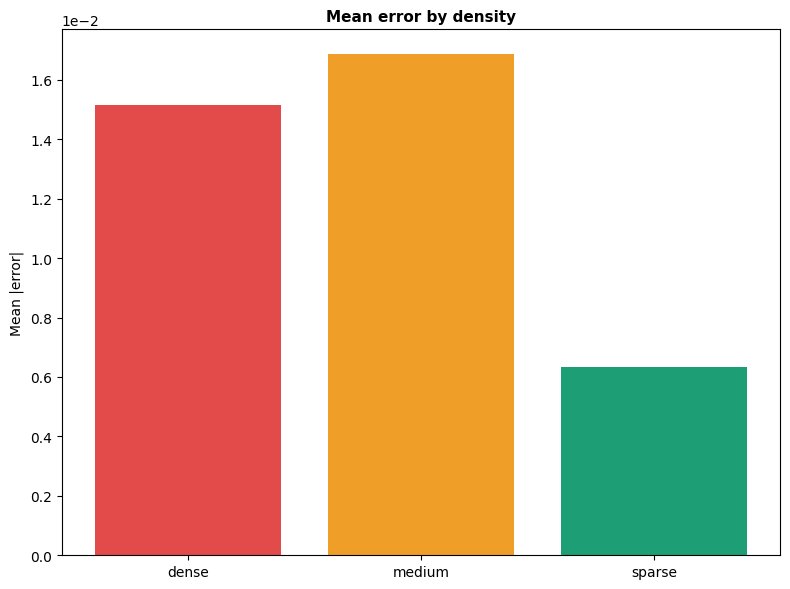

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

g_dens = df.groupby("Density")["Absolute_Error"].mean()
ax.bar(g_dens.index, g_dens.values,
       color=[COLORS[d] for d in g_dens.index], edgecolor="none")

ax.set_title("Mean error by density", fontsize=11, fontweight="bold")
ax.set_ylabel("Mean |error|")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

plt.tight_layout()
plt.savefig("1_mean_error_by_density.png", dpi=150, bbox_inches="tight")
plt.show()

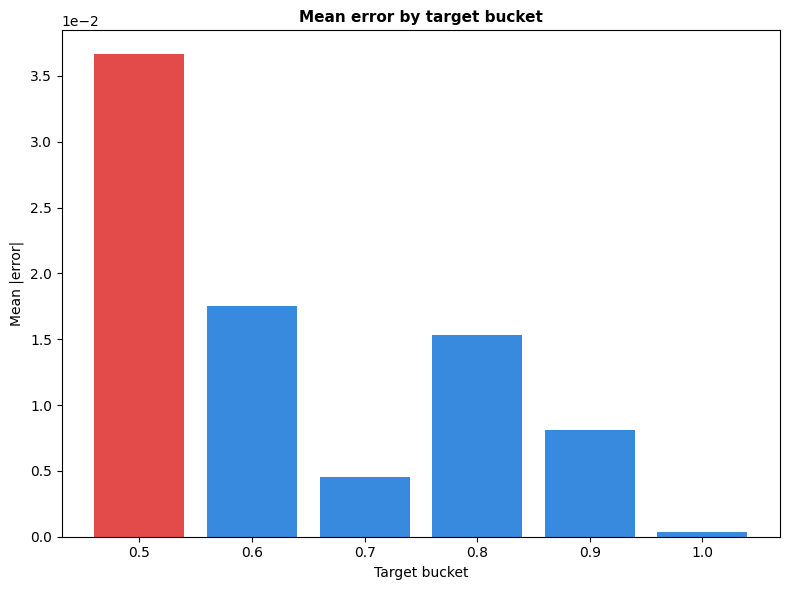

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

g_bkt = df.groupby("Target_Bucket")["Absolute_Error"].mean()
bar_colors = ["#E24B4A" if v == g_bkt.max() else "#378ADD" for v in g_bkt.values]
ax.bar([str(b) for b in g_bkt.index], g_bkt.values,
       color=bar_colors, edgecolor="none")

ax.set_title("Mean error by target bucket", fontsize=11, fontweight="bold")
ax.set_xlabel("Target bucket")
ax.set_ylabel("Mean |error|")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

plt.tight_layout()
plt.savefig("2_mean_error_by_target_bucket.png", dpi=150, bbox_inches="tight")
plt.show()

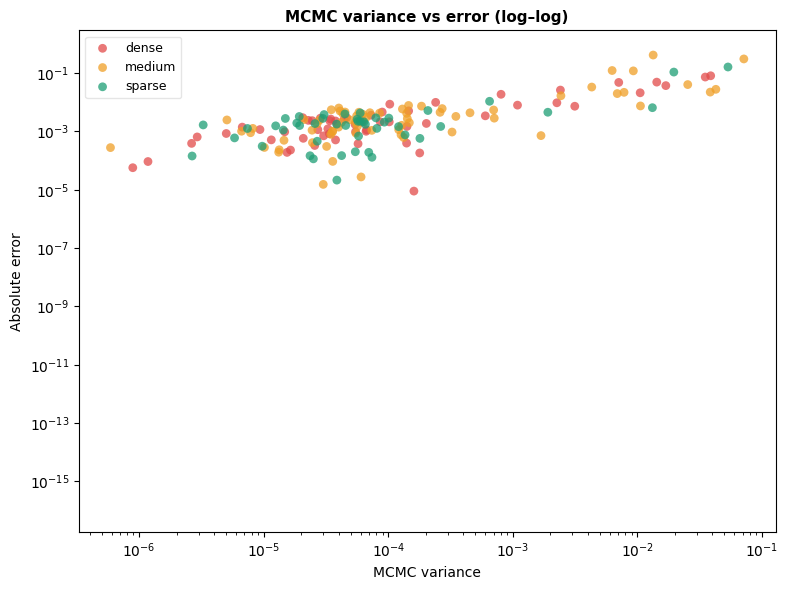

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for dens, grp in df.groupby("Density"):
    ax.scatter(grp["MCMC_Variance"], grp["Absolute_Error"],
               label=dens, color=COLORS[dens], alpha=0.75, s=40, edgecolors="none")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("MCMC variance vs error (log–log)", fontsize=11, fontweight="bold")
ax.set_xlabel("MCMC variance")
ax.set_ylabel("Absolute error")
ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.savefig("3_mcmc_variance_vs_error.png", dpi=150, bbox_inches="tight")
plt.show()

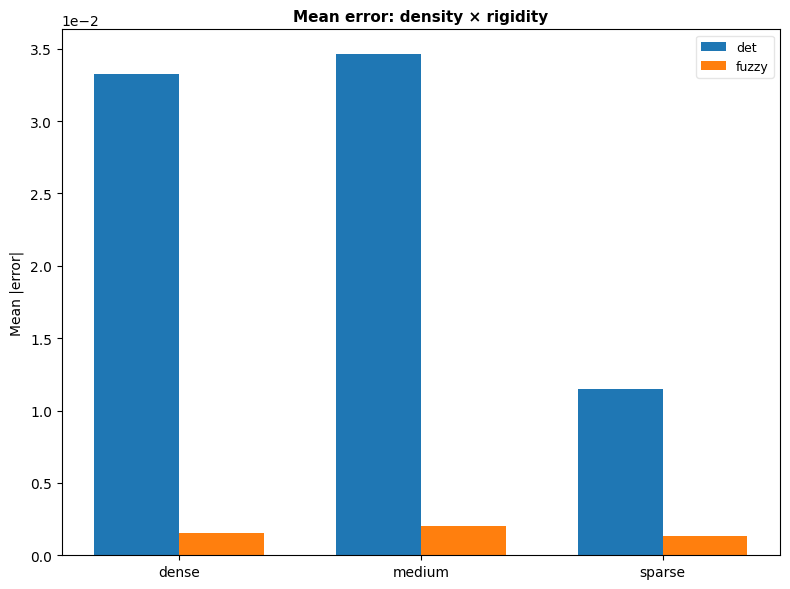

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

pivot2 = df.pivot_table(
    values="Absolute_Error", index="Density", columns="Rigidity", aggfunc="mean"
)
x = np.arange(len(pivot2.index))
w = 0.35
rigs = pivot2.columns.tolist()

for i, rig in enumerate(rigs):
    ax.bar(x + i * w, pivot2[rig], w, label=rig, edgecolor="none")

ax.set_xticks(x + w / 2)
ax.set_xticklabels(pivot2.index)
ax.set_title("Mean error: density × rigidity", fontsize=11, fontweight="bold")
ax.set_ylabel("Mean |error|")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.savefig("4_mean_error_density_rigidity.png", dpi=150, bbox_inches="tight")
plt.show()

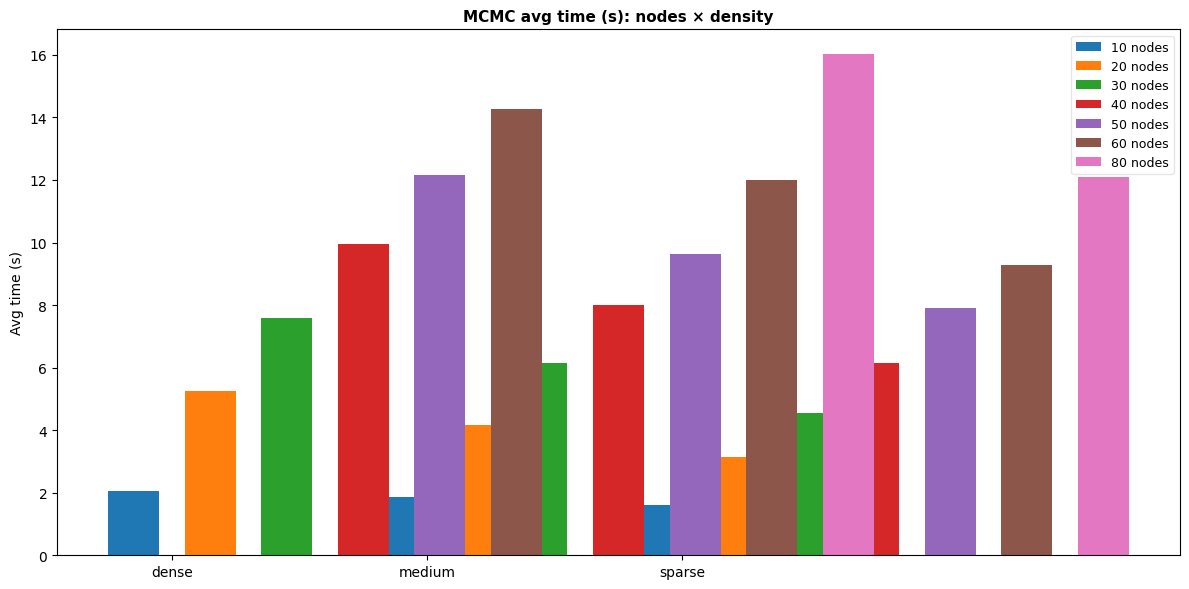

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

timing = df.groupby(["N_Nodes", "Density"])["MCMC_Avg_Time_sec"].mean().unstack()
densities = timing.columns.tolist()
x = np.arange(len(densities))

for i, (n, row) in enumerate(timing.iterrows()):
    offset = (i - 0.5) * 0.3
    ax.bar(x + offset, row[densities], 0.20,
           label=f"{n} nodes", edgecolor="none")

ax.set_xticks(x)
ax.set_xticklabels(densities)
ax.set_title("MCMC avg time (s): nodes × density", fontsize=11, fontweight="bold")
ax.set_ylabel("Avg time (s)")
ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.savefig("5_mcmc_timing_nodes_density.png", dpi=150, bbox_inches="tight")
plt.show()

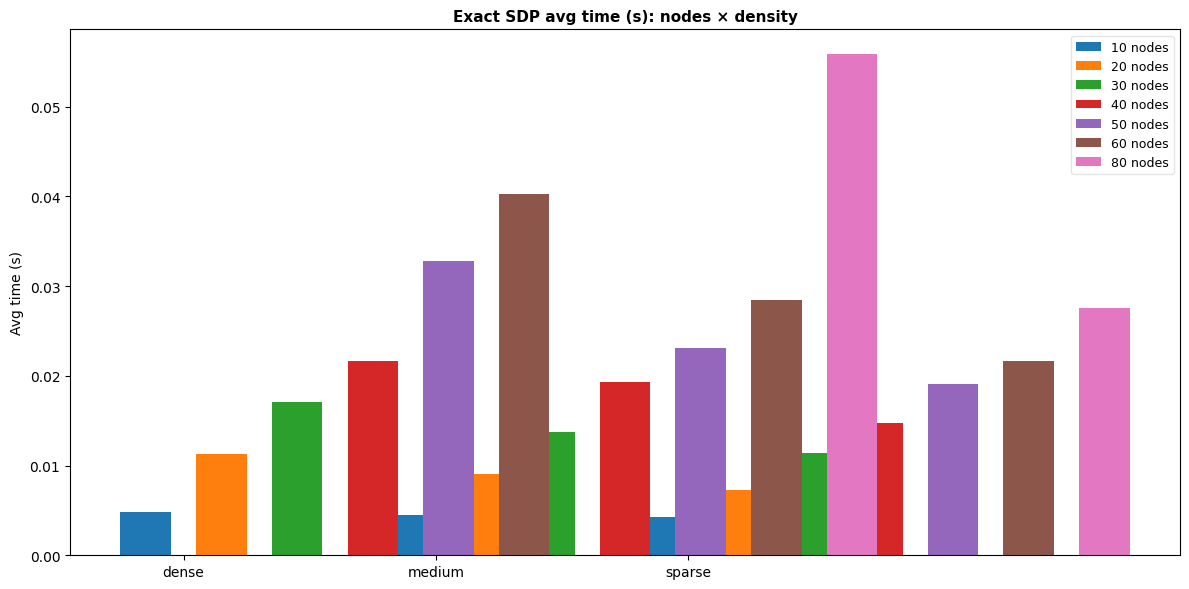

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))

timing = df.groupby(["N_Nodes", "Density"])["Exact_Time_sec"].mean().unstack()
densities = timing.columns.tolist()
x = np.arange(len(densities))

for i, (n, row) in enumerate(timing.iterrows()):
    offset = (i - 0.5) * 0.3
    ax.bar(x + offset, row[densities], 0.20,
           label=f"{n} nodes", edgecolor="none")

ax.set_xticks(x)
ax.set_xticklabels(densities)
ax.set_title("Exact SDP avg time (s): nodes × density", fontsize=11, fontweight="bold")
ax.set_ylabel("Avg time (s)")
ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.savefig("6_exact_sdp_timing_nodes_density.png", dpi=150, bbox_inches="tight")
plt.show()

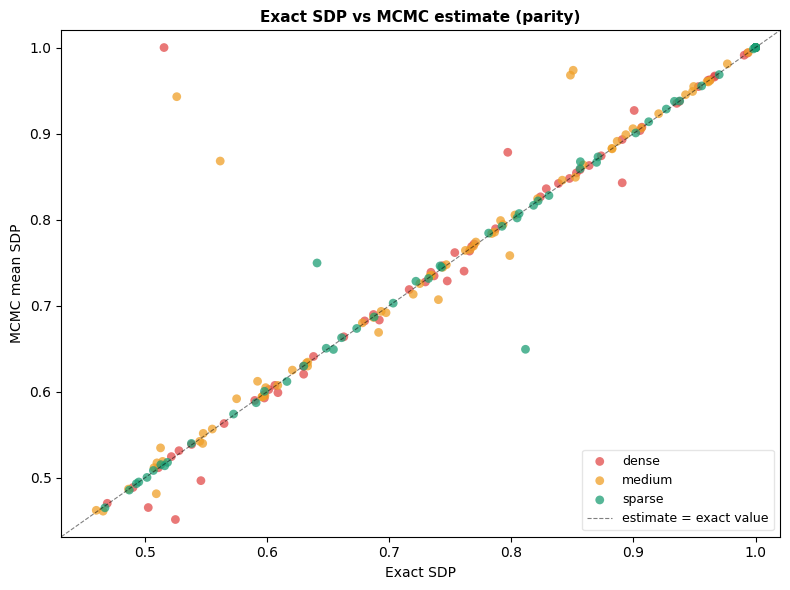

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

for dens, grp in df.groupby("Density"):
    ax.scatter(grp["Exact_SDP"], grp["MCMC_Mean_SDP"],
               label=dens, color=COLORS[dens], alpha=0.75, s=40, edgecolors="none")

lims = [df[["Exact_SDP", "MCMC_Mean_SDP"]].min().min() - 0.02,
        df[["Exact_SDP", "MCMC_Mean_SDP"]].max().max() + 0.02]

ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5, label="estimate = exact value")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Exact SDP vs MCMC estimate (parity)", fontsize=11, fontweight="bold")
ax.set_xlabel("Exact SDP")
ax.set_ylabel("MCMC mean SDP")
ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.savefig("6_exact_vs_mcmc_parity.png", dpi=150, bbox_inches="tight")
plt.show()

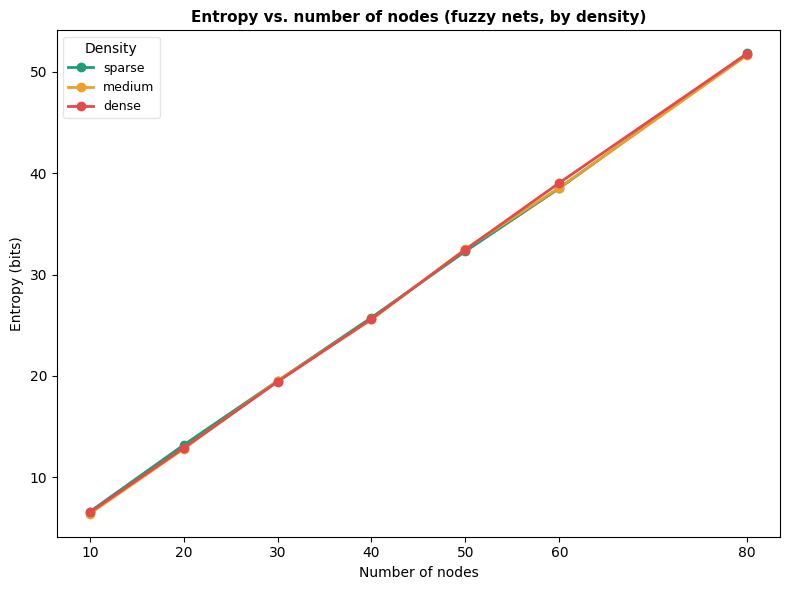

In [26]:
# for the same number of nodes and only fuzzy nets, how entropy varies with density?
edf = pd.read_csv("synthetic_bn_entropies.csv")
edf[["N_Nodes", "Density", "Rigidity"]] = edf["Network"].str.extract(
    r"bn_n(\d+)_w\d+_(sparse|medium|dense)_(fuzzy|det)\.bif"
)
edf["N_Nodes"] = edf["N_Nodes"].astype(int)

fuzzy = edf[edf["Rigidity"] == "fuzzy"].sort_values("N_Nodes")

fig, ax = plt.subplots(figsize=(8, 6))

density_order = ["sparse", "medium", "dense"]
for dens in density_order:
    sub = fuzzy[fuzzy["Density"] == dens].sort_values("N_Nodes")
    ax.plot(sub["N_Nodes"], sub["entropy"],
            marker="o", label=dens, color=COLORS[dens], linewidth=2)

ax.set_title("Entropy vs. number of nodes (fuzzy nets, by density)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Number of nodes")
ax.set_ylabel("Entropy (bits)")
ax.legend(title="Density", fontsize=9, framealpha=0.5)
ax.set_xticks(sorted(fuzzy["N_Nodes"].unique()))

plt.tight_layout()
plt.savefig("entropy_vs_nodes_by_density.png", dpi=150, bbox_inches="tight")
plt.show()

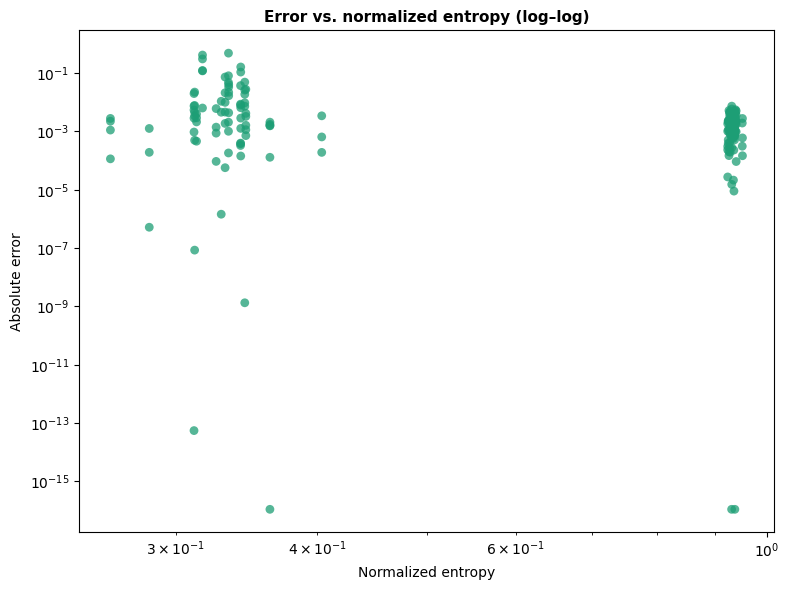

In [28]:
# error by column entropy_normalized
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["entropy_normalized"], df["Absolute_Error"],
           color="#1D9E75", alpha=0.75, s=40, edgecolors="none")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Error vs. normalized entropy (log–log)", fontsize=11, fontweight="bold")
ax.set_xlabel("Normalized entropy")
ax.set_ylabel("Absolute error")
plt.tight_layout()
plt.savefig("error_vs_normalized_entropy.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
import seaborn as sns
from scipy.stats import spearmanr

def analyze_entropy_threshold(df_path_or_obj):
    # Load DF if path is given, else use the object
    if isinstance(df_path_or_obj, str):
        df = pd.read_csv(df_path_or_obj)
    else:
        df = df_path_or_obj
        
    # Drop rows where Exact SDP crashed (since we can't calculate Absolute Error)
    valid_df = df.dropna(subset=['entropy_normalized', 'Absolute_Error']).copy()
    
    print("==================================================")
    print("      MCMC ERROR vs. NORMALIZED ENTROPY           ")
    print("==================================================\n")
    
    # 1. Non-Linear Correlation (Spearman)
    # We use Spearman because the error spike is likely a sudden curve, not a straight line.
    corr, pval = spearmanr(valid_df['entropy_normalized'], valid_df['Absolute_Error'])
    print(f"Spearman Correlation: {corr:.4f} (p-value: {pval:.3e})")
    print("  * A strong negative correlation means lower entropy = higher error.\n")
    
    # 2. Find the exact threshold using Binning
    print("--- Error Threshold by Entropy Bins ---")
    # Divide the 0-1 entropy scale into 10 buckets
    bins = np.linspace(0, 1.0, 11) 
    valid_df['Entropy_Bin'] = pd.cut(valid_df['entropy_normalized'], bins=bins)
    
    bin_summary = valid_df.groupby('Entropy_Bin')['Absolute_Error'].agg(
        Mean_Error='mean',
        Max_Error='max',
        Networks_Count='count'
    )
    print(bin_summary)
    
    # Identify the safest threshold (where Max Error stays strictly below 5%)
    safe_bins = bin_summary[bin_summary['Max_Error'] < 0.05]
    if not safe_bins.empty:
        # Get the lowest entropy bin that is still "safe"
        threshold_bin = safe_bins.index[0]
        print(f"\n[+] EMPIRICAL THRESHOLD FOUND:")
        print(f"    MCMC remains highly reliable (Max Error < 5%) when Normalized Entropy is > {threshold_bin.left}")
    
    # 3. Generate the Publication Plot
    plt.figure(figsize=(10, 6))
    
    # Scatter the actual network results
    sns.scatterplot(
        data=valid_df, 
        x='entropy_normalized', 
        y='Absolute_Error', 
        hue='Rigidity',
        palette={'det': '#e74c3c', 'fuzzy': '#3498db'},
        s=80, alpha=0.7, edgecolor='k'
    )
    
    # Add a LOWESS (Locally Weighted Scatterplot Smoothing) trendline to show the phase transition
    sns.regplot(
        data=valid_df, 
        x='entropy_normalized', 
        y='Absolute_Error', 
        scatter=False, 
        color='black', 
        lowess=True, 
        line_kws={'linestyle': '--', 'linewidth': 2},
        label='Average Error Trend'
    )
    
    # Add an "Acceptable Error" boundary line
    plt.axhline(0.01, color='gray', linestyle=':', label='1% Error Boundary')
    plt.axhline(0.05, color='red', linestyle=':', label='5% Error Boundary')
    
    # Formatting
    plt.title('MCMC Reliability across Network Entropy', fontsize=14, fontweight='bold')
    plt.xlabel('Normalized Entropy (0 = Deterministic/Rigid, 1 = Maximum Randomness)', fontsize=12)
    plt.ylabel('MCMC Absolute Error', fontsize=12)
    plt.xlim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

      MCMC ERROR vs. NORMALIZED ENTROPY           

Spearman Correlation: -0.1803 (p-value: 1.121e-02)
  * A strong negative correlation means lower entropy = higher error.

--- Error Threshold by Entropy Bins ---
             Mean_Error  Max_Error  Networks_Count
Entropy_Bin                                       
(0.0, 0.1]          NaN        NaN               0
(0.1, 0.2]          NaN        NaN               0
(0.2, 0.3]     0.000967   0.002800               8
(0.3, 0.4]     0.030624   0.484307              79
(0.4, 0.5]     0.001426   0.003438               3
(0.5, 0.6]          NaN        NaN               0
(0.6, 0.7]          NaN        NaN               0
(0.7, 0.8]          NaN        NaN               0
(0.8, 0.9]          NaN        NaN               0
(0.9, 1.0]     0.001704   0.007385             107

[+] EMPIRICAL THRESHOLD FOUND:
    MCMC remains highly reliable (Max Error < 5%) when Normalized Entropy is > 0.2


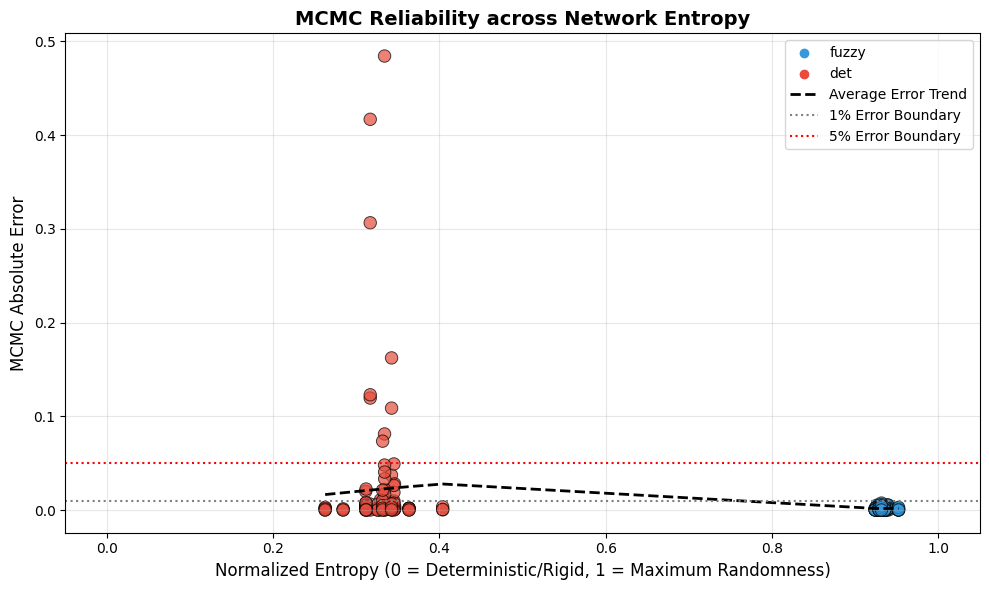

In [33]:
analyze_entropy_threshold(df)